<a href="https://colab.research.google.com/github/Umukundwa004/Summative-MLOP/blob/main/voice_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scipy import ndimage
import warnings
import pickle

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


In [6]:
#configurations
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
TRAIN_DIR = '/kaggle/input/brain-tumor-mri-dataset/Training'
TEST_DIR = '/kaggle/input/brain-tumor-mri-dataset/Testing'


In [7]:


# Extract key image features across all classes for statistical EDA
data = []

for category in CLASSES:
    folder_path = os.path.join(TRAIN_DIR, category)
    if not os.path.exists(folder_path):
        continue
    for img_name in os.listdir(folder_path)[:200]:  # Sample 200 images per class
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Feature 1: Mean Intensity (Brightness)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mean_intensity = np.mean(gray)

        # Feature 2: Intensity Standard Deviation (Contrast)
        std_intensity = np.std(gray)

        # Feature 3: Aspect Ratio (Width / Height)
        h, w, _ = img.shape
        aspect_ratio = w / h

        data.append({
            'Class': category,
            'Mean_Intensity': mean_intensity,
            'Std_Dev_Contrast': std_intensity,
            'Aspect_Ratio': aspect_ratio
        })

df_eda = pd.DataFrame(data)
df_eda.head()

""


Accessing Kaggle dataset at: C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Training

Found 4 class folder(s): ['glioma', 'meningioma', 'notumor', 'pituitary']

Processing 'glioma': found 300 images
Processing 'meningioma': found 300 images
Processing 'notumor': found 300 images
Processing 'pituitary': found 300 images

 Successfully loaded 1200 image metrics into df_eda!


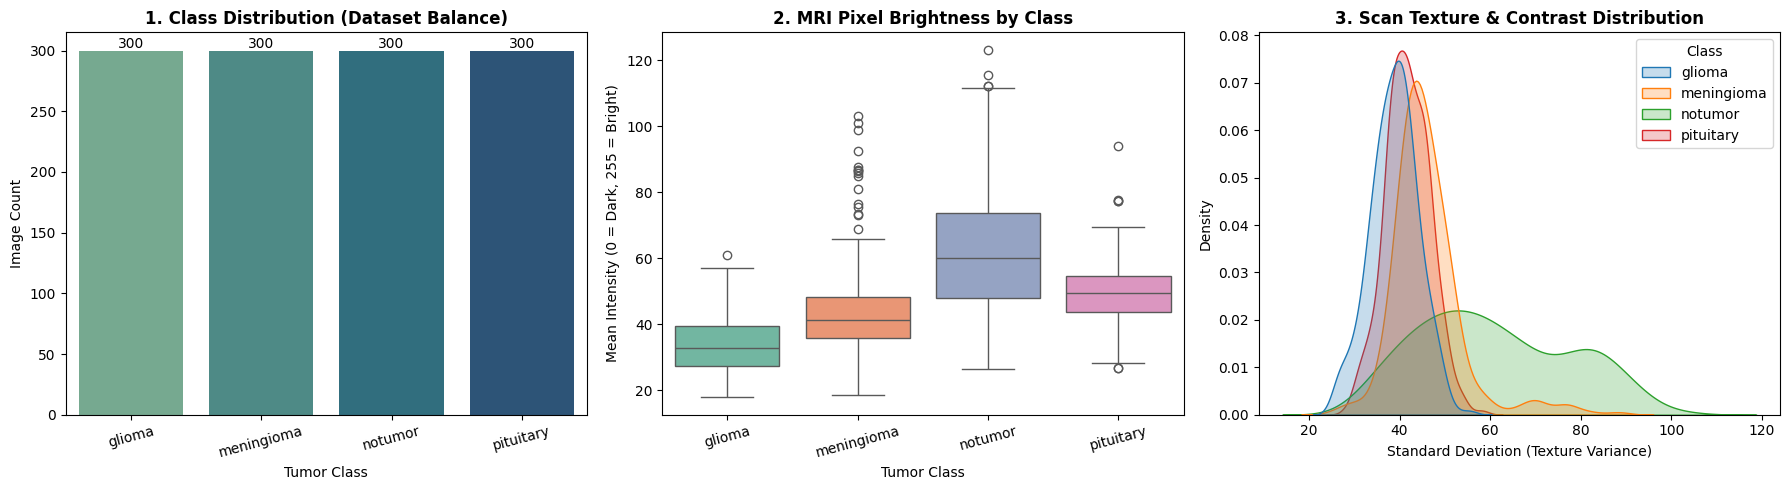

In [15]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Exact kagglehub cache directory from your log output
DATASET_PATH = Path(r"C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2")

# Check for 'Training' or 'train' inside the Kaggle download folder
TRAIN_DIR = DATASET_PATH / "Training"
if not TRAIN_DIR.exists():
    TRAIN_DIR = DATASET_PATH / "train"

print(f"Accessing Kaggle dataset at: {TRAIN_DIR.resolve()}\n")

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"❌ Could not locate training folder inside: {DATASET_PATH}")

# Auto-detect class subfolders (glioma, meningioma, notumor, pituitary)
class_folders = [f for f in TRAIN_DIR.iterdir() if f.is_dir()]
print(f"Found {len(class_folders)} class folder(s): {[f.name for f in class_folders]}\n")

# --- EXTRACT METRICS FOR EDA ---
records = []

for folder in class_folders:
    category = folder.name  # Use exact folder name
    
    # Grab image paths
    image_paths = [
        p for p in folder.iterdir() 
        if p.suffix.lower() in ['.jpg', '.jpeg', '.png']
    ][:300]  # Sample up to 300 per class for speed
    
    print(f"Processing '{category}': found {len(image_paths)} images")
    
    for img_path in image_paths:
        try:
            with Image.open(img_path) as img:
                gray = np.array(img.convert('L'))
                records.append({
                    'Class': category,
                    'Mean_Brightness': float(np.mean(gray)),
                    'Contrast_Std': float(np.std(gray))
                })
        except Exception:
            continue

df_eda = pd.DataFrame(records)

if df_eda.empty:
    raise ValueError("df_eda is empty! No images could be loaded.")

print(f"\n Successfully loaded {len(df_eda)} image metrics into df_eda!")

# --- GENERATE EDA PLOTS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Class Balance
counts = df_eda['Class'].value_counts()
sns.barplot(
    x=counts.index, 
    y=counts.values, 
    ax=axes[0], 
    palette='crest', 
    hue=counts.index, 
    legend=False
)
axes[0].set_title('1. Class Distribution (Dataset Balance)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Image Count')
axes[0].set_xlabel('Tumor Class')
axes[0].tick_params(axis='x', rotation=15)

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f'{int(height)}', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center', 
            xytext=(0, 5), 
            textcoords='offset points'
        )

# Plot 2: Pixel Brightness
sns.boxplot(
    data=df_eda, 
    x='Class', 
    y='Mean_Brightness', 
    ax=axes[1], 
    palette='Set2', 
    hue='Class', 
    legend=False
)
axes[1].set_title('2. MRI Pixel Brightness by Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Intensity (0 = Dark, 255 = Bright)')
axes[1].set_xlabel('Tumor Class')
axes[1].tick_params(axis='x', rotation=15)

# Plot 3: Image Contrast
sns.kdeplot(
    data=df_eda, 
    x='Contrast_Std', 
    hue='Class', 
    fill=True, 
    ax=axes[2], 
    common_norm=False, 
    palette='tab10'
)
axes[2].set_title('3. Scan Texture & Contrast Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Standard Deviation (Texture Variance)')

plt.tight_layout()
plt.show()

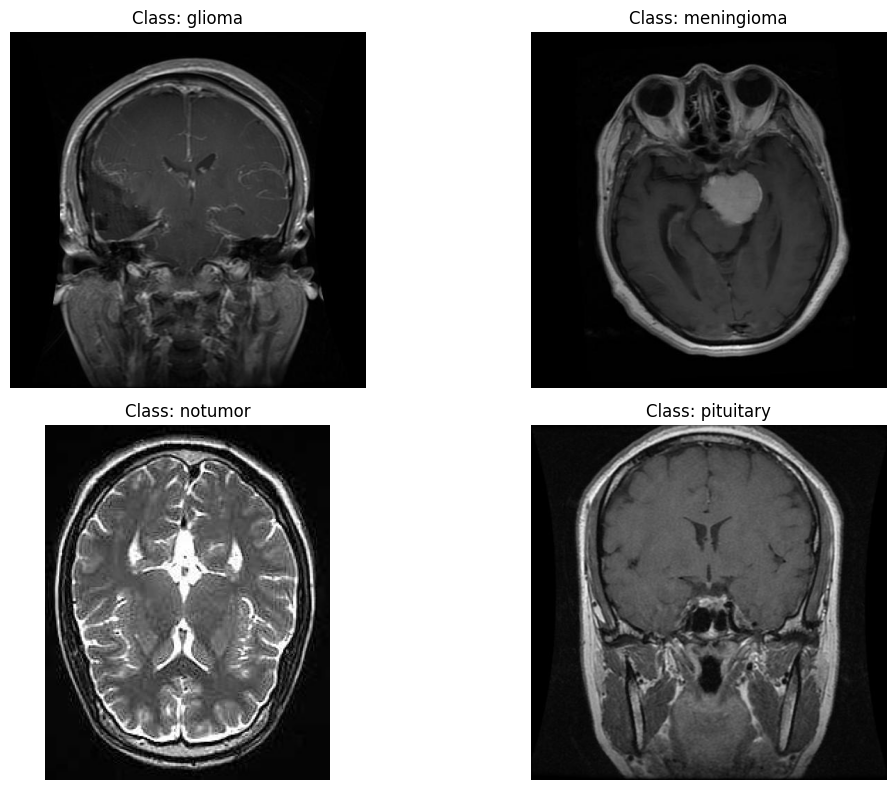

In [9]:
plt.figure(figsize=(12, 8))
for i, category in enumerate(CLASSES):
    folder = os.path.join(TRAIN_DIR, category)
    img_name = os.listdir(folder)[0]
    img = cv2.imread(os.path.join(folder, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {category}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
import os
from pathlib import Path

# --- LOCAL KAGGLEHUB CACHE PATHS ---
DATASET_PATH = Path(r"C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2")

TRAIN_DIR = str(DATASET_PATH / "Training")
TEST_DIR = str(DATASET_PATH / "Testing")

print("Train Directory:", TRAIN_DIR)
print("Test Directory: ", TEST_DIR)

Train Directory: C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Training
Test Directory:  C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Testing


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [12]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Ensure models directory exists
os.makedirs("../models", exist_ok=True)
model_save_path = "../models/brain_tumor_model.keras"

# 1. Define Custom CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes: glioma, meningioma, notumor, pituitary
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Callbacks for Best Model Saving
checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor="val_accuracy",     # Save based on best validation accuracy
    mode="max",
    save_best_only=True,         # Overwrites ONLY when val_accuracy improves
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,                  # Stop if no validation improvement for 3 epochs
    restore_best_weights=True
)

# 3. Train Model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=[checkpoint, early_stopping]
)

print(f"\n✅ Training complete!")

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5938 - loss: 0.9313
Epoch 1: val_accuracy improved from None to 0.58875, saving model to ../models/brain_tumor_model.keras

Epoch 1: finished saving model to ../models/brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.5938 - loss: 0.9313 - val_accuracy: 0.5888 - val_loss: 1.7063
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7307 - loss: 0.6628
Epoch 2: val_accuracy improved from 0.58875 to 0.72438, saving model to ../models/brain_tumor_model.keras

Epoch 2: finished saving model to ../models/brain_tumor_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.7307 - loss: 0.6628 - val_accuracy: 0.7244 - val_loss: 0.9946
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7682 - loss: 0.5732
Epoch 3: val_accuracy did not improve from 0.72438
175/175 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.7682 - loss: 0.5732 - val_accuracy: 0.7050 - val_loss: 

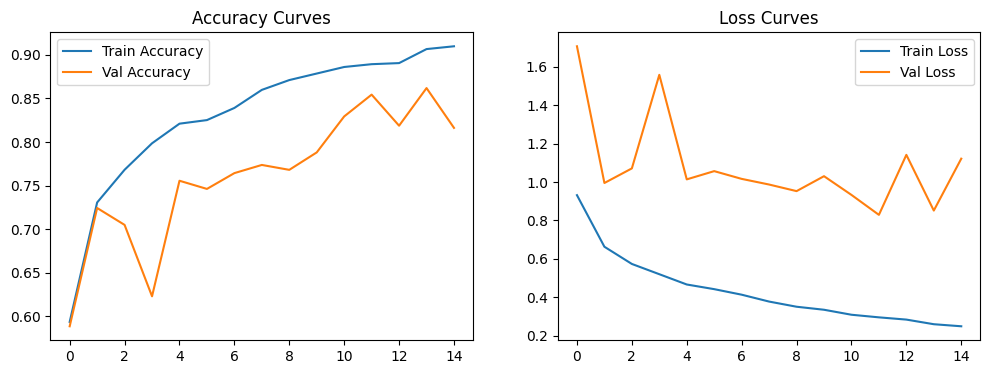

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step
              precision    recall  f1-score   support

      glioma       0.93      0.70      0.80       400
  meningioma       0.83      0.80      0.81       400
     notumor       0.79      0.99      0.88       400
   pituitary       0.94      0.95      0.94       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600


Model Evaluation Results Table:
   Metric    Value
 Accuracy 0.861875
Precision 0.870305
   Recall 0.861875
 F1-Score 0.859073


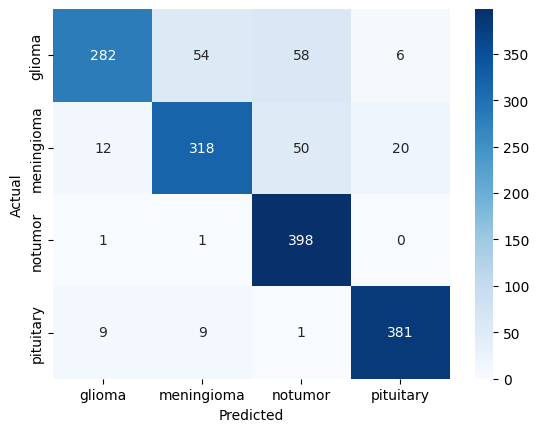

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Plot Accuracy and Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Classification Report & Confusion Matrix
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=CLASSES))

# Re-calculate metrics for the table display
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

results_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [acc, prec, rec, f1]
}
results_df = pd.DataFrame(results_data)

print("\nModel Evaluation Results Table:")
print(results_df.to_string(index=False))


cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import os
import shutil
from pathlib import Path

# Source: Kagglehub local cache
CACHE_DIR = Path(r"C:\Users\LENOVO\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2")

# Destination: Your project's data directory
# Adjust path if running inside notebook folder: Path.cwd().parent / "data"
PROJECT_DATA = Path("data") if Path.cwd().name != "notebook" else Path.cwd().parent / "data"

DEST_TRAIN = PROJECT_DATA / "train"
DEST_TEST = PROJECT_DATA / "test"

if CACHE_DIR.exists():
    print(" Copying dataset from system cache into your project's data folder...")

    # Copy Training Data
    if (CACHE_DIR / "Training").exists() and not (DEST_TRAIN / "glioma").exists():
        shutil.copytree(CACHE_DIR / "Training", DEST_TRAIN, dirs_exist_ok=True)
        print(" Copied 'Training' -> 'data/train'")

    # Copy Testing Data
    if (CACHE_DIR / "Testing").exists() and not (DEST_TEST / "glioma").exists():
        shutil.copytree(CACHE_DIR / "Testing", DEST_TEST, dirs_exist_ok=True)
        print(" Copied 'Testing' -> 'data/test'")

    print("\n Done! Your project data folder is now fully populated.")
else:
    print("Cache directory not found. Please re-run your kagglehub download step.")

 Copying dataset from system cache into your project's data folder...

 Done! Your project data folder is now fully populated.
